In [32]:
# output data

import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import pygmt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# defining appropriate grid
lon_min, lon_max = 65.5, 114.5
lat_min, lat_max = 10.5, 44.5
d_res = 0.25

lons = np.arange(lon_min, lon_max + d_res / 2, d_res)
lats = np.arange(lat_min, lat_max + d_res / 2, d_res)
gx, gy = np.meshgrid(lons, lats)

# read model output data
df = pd.read_csv('../aspect_tests/output_test_106/slices/dynamic_topography_depth_0km_t0.csv')
aspect_lon = df['Points:0'].to_numpy()
aspect_lat = df['Points:1'].to_numpy()
topo = df['dynamic_topography'].to_numpy()

# resampling model output data grid
aspect_grid = griddata((aspect_lon, aspect_lat), topo, (gx, gy), method='linear')

In [33]:
# observed data - topography

# load topography data from pygmt
grid = pygmt.datasets.load_earth_relief(resolution='06m', region=[lon_min, lon_max, lat_min, lat_max])
obs_raw = grid.values
obs_lons = grid.coords['lon'].values
obs_lats = grid.coords['lat'].values

# apply gaussian filter of 100km wavelength
sigma_cells = 1.0 / (obs_lons[1] - obs_lons[0])
obs_smooth = gaussian_filter(obs_raw, sigma=sigma_cells)

# resample data to match resampled output data grid
interp = RegularGridInterpolator((obs_lats, obs_lons), obs_smooth)
obs_grid = interp(np.column_stack([gy.ravel(), gx.ravel()])).reshape(gx.shape)

In [34]:
# to extract and save strain rate for a region

# gsrm_file = '../Global_strain_rate/GSRM_average_strain_v2.1.txt'
# seconds = 365.25 * 24.0 * 3600.0  
# ns_per_s = 1e-9 / seconds
# col_names = ['lat','lon','exx_raw','eyy_raw','exy_raw','vorticity_raw','RL_NLC','LL_NLC','e1_raw','e2_raw','azi_e1',]
# chunks = []
# for chunk in pd.read_csv(gsrm_file, comment='#', sep=r'\s+', header=None, names=col_names, chunksize=200000,):
#     mask = ((chunk['lon'] >= lon_min) & (chunk['lon'] <= lon_max) & (chunk['lat'] >= lat_min) & (chunk['lat'] <= lat_max))
#     filtered = chunk[mask]
#     if not filtered.empty:
#         chunks.append(filtered)

# df = pd.concat(chunks, ignore_index=True)


# e1 = df['e1_raw'].to_numpy() * ns_per_s
# e2 = df['e2_raw'].to_numpy() * ns_per_s
# strain_rate_2nd_inv = np.sqrt(e1**2 + e1 * e2 + e2**2)
# log10_strain_rate = np.log10(np.maximum(strain_rate_2nd_inv, 1e-18))
# max_shear = 0.5 * np.abs(e1 - e2)
# dilatation = e1 + e2

# df['strain_rate_2nd_inv'] = strain_rate_2nd_inv
# df['log10_strain_rate'] = log10_strain_rate
# df['max_shear'] = max_shear
# df['dilatation'] = dilatation
# lons = np.sort(df['lon'].unique())
# lats = np.sort(df['lat'].unique())

# grid_strain = df.pivot(index='lat', columns='lon', values='strain_rate_2nd_inv').to_numpy()
# grid_log10 = df.pivot(index='lat', columns='lon', values='log10_strain_rate').to_numpy()
# grid_shear = df.pivot(index='lat', columns='lon', values='max_shear').to_numpy()
# grid_dilat = df.pivot(index='lat', columns='lon', values='dilatation').to_numpy()


# np.savez_compressed('../Global_strain_rate/GSRM_tibet_grid.npz', lons=lons, lats=lats, strain_rate_2nd_inv=grid_strain, log10_strain_rate=grid_log10, max_shear=grid_shear, dilatation=grid_dilat,)

In [35]:
# compute misfit

misfit_topo = aspect_grid - obs_grid

# point above sea level
valid = ~np.isnan(aspect_grid) & ~np.isnan(obs_grid)
obs_valid = obs_grid[valid]
mod_valid = aspect_grid[valid]
diff = mod_valid - obs_valid

# calculate metrics
mean_bias = np.mean(diff)
mae = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
r_corr, _ = pearsonr(obs_valid, mod_valid)

print(f'RMSE: {rmse:.2f}, Mean Bias: {mean_bias:+.2f}, Pearson R: {r_corr:.2f}')

RMSE: 1486.66, Mean Bias: -664.23, Pearson R: 0.90


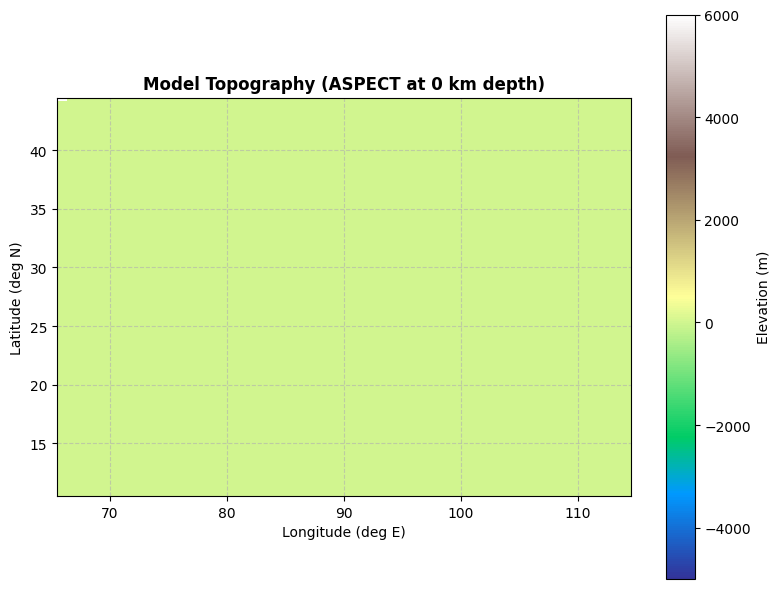

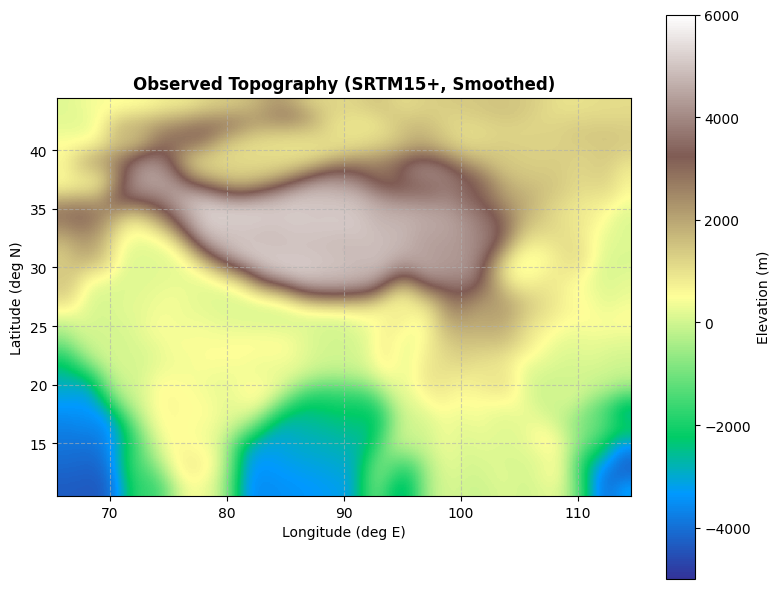

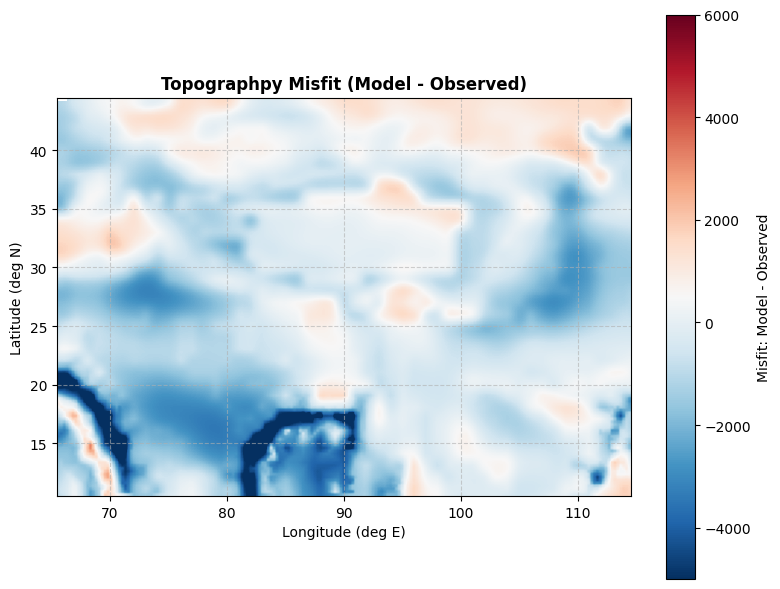

In [39]:
# plot - topography

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(aspect_grid, origin='lower', extent=extent, cmap='terrain', vmin=-5000, vmax=6000)
ax.set_title('Model Topography (ASPECT at 0 km depth)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('Elevation (m)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
#plt.savefig('../aspect_tests/output_test_106/topography_comparision/topography_aspect_0.25deg.png', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(obs_grid, origin='lower', extent=extent, cmap='terrain', vmin=-5000, vmax=6000)
ax.set_title('Observed Topography (SRTM15+, Smoothed)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('Elevation (m)')
ax.grid(True, linestyle='--', alpha=0.6)
#plt.savefig('../aspect_tests/output_test_106/topography_comparision/topography_observed_0.25deg.png', dpi=300)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(misfit_topo, origin='lower', extent=extent, cmap='RdBu_r', vmin=-5000, vmax=6000)
ax.set_title('Topographpy Misfit (Model - Observed)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('Misfit: Model - Observed')
ax.grid(True, linestyle='--', alpha=0.6)
#plt.savefig('../aspect_tests/output_test_106/topography_comparision/topography_misfit_0.25deg.png', dpi=300)
plt.tight_layout()
plt.show()

In [36]:
# observed data - strain rate

gsrm = np.load('../Global_strain_rate/GSRM_tibet_grid.npz')
obs_log10_raw = gsrm['log10_strain_rate']
glons, glats = gsrm['lons'], gsrm['lats']

# gaussian smoothing
sigma_cells = 1.0 / (glons[1] - glons[0])
gsrm_smooth = gaussian_filter(obs_log10_raw, sigma=sigma_cells)
interp = RegularGridInterpolator((glats, glons), gsrm_smooth)
obs_grid_strain = interp(np.column_stack([gy.ravel(), gx.ravel()])).reshape(gx.shape)

In [37]:
# output data - strain rate

df = pd.read_csv('../aspect_tests/output_test_106/slices/strain_rate_depth_0km_t0.csv')
aspect_lon = df['Points:0'].to_numpy()
aspect_lat = df['Points:1'].to_numpy()
strain_rate = df['strain_rate'].to_numpy()
aspect_grid = griddata((aspect_lon, aspect_lat), strain_rate, (gx, gy), method='linear')
aspect_grid_strain = np.log10(np.maximum(aspect_grid, 1e-20))

In [38]:
# compute misfit

misfit_strain = aspect_grid_strain - obs_grid_strain

# point above sea level
valid = ~np.isnan(aspect_grid) & ~np.isnan(obs_grid)
obs_valid = obs_grid[valid]
mod_valid = aspect_grid[valid]
diff = mod_valid - obs_valid

# calculate metrics
mean_bias = np.mean(diff)
mae = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
r_corr, _ = pearsonr(obs_valid, mod_valid)

print(f'RMSE: {rmse:.2f}, Mean Bias: {mean_bias:+.2f}, Pearson R: {r_corr:.2f}')

RMSE: 2212.40, Mean Bias: -901.66, Pearson R: 0.58


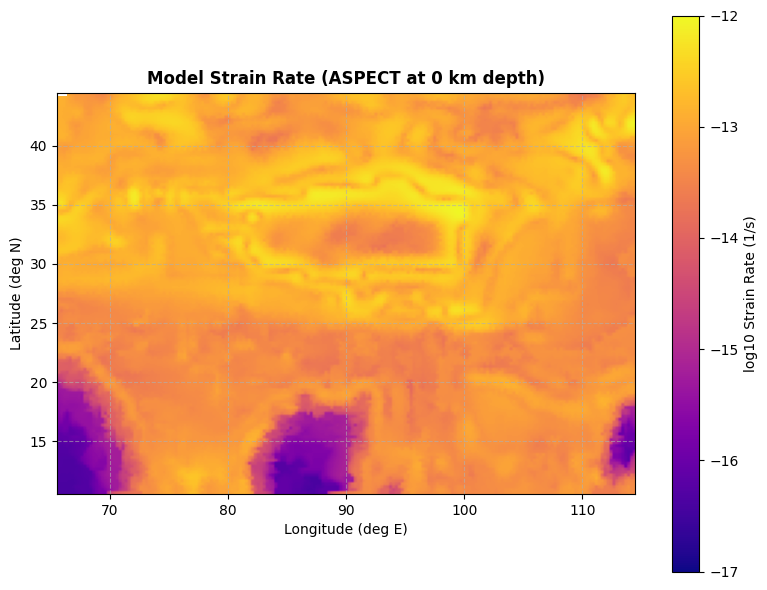

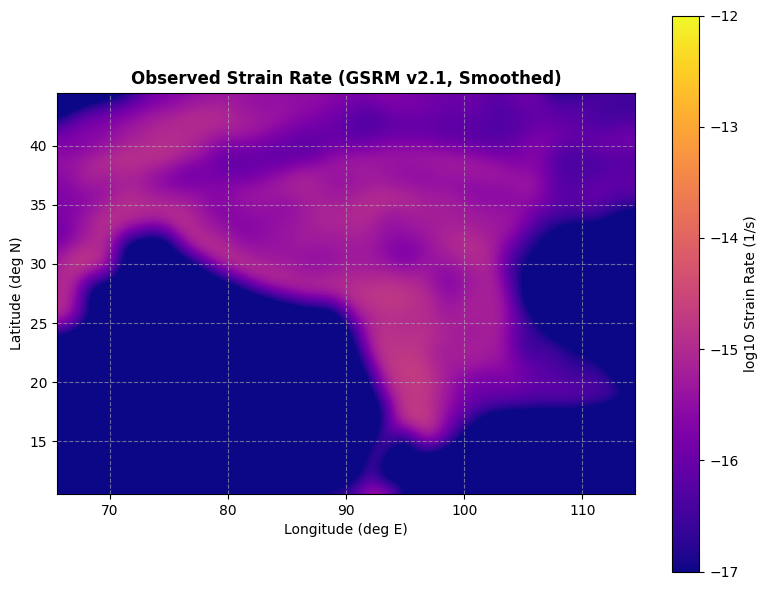

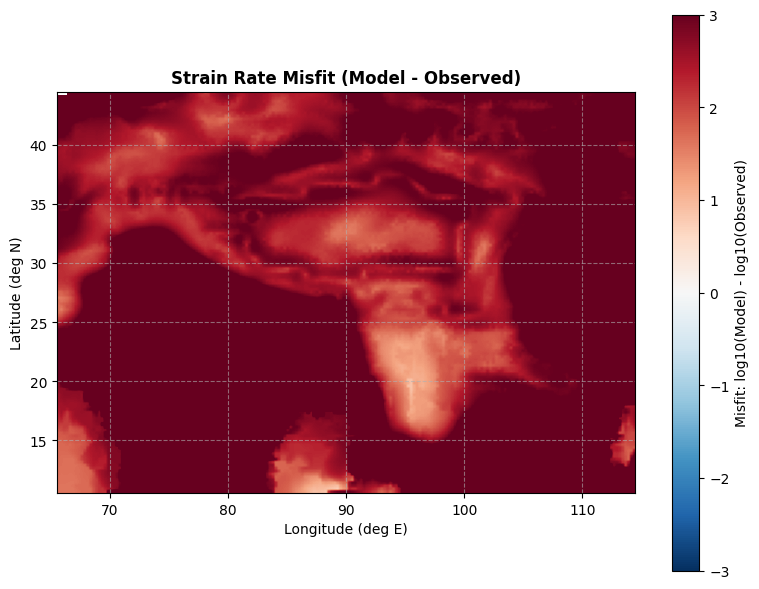

In [40]:
# plot - strain rate

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(aspect_grid_strain, origin='lower', extent=extent, cmap='plasma', vmin=-17.0, vmax=-12.0)
ax.set_title('Model Strain Rate (ASPECT at 0 km depth)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('log10 Strain Rate (1/s)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig('../aspect_tests/output_test_106/strain_rate_comparison/strain_rate_aspect_0.25deg.png', dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(obs_grid_strain, origin='lower', extent=extent, cmap='plasma', vmin=-17.0, vmax=-12.0,)
ax.set_title('Observed Strain Rate (GSRM v2.1, Smoothed)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('log10 Strain Rate (1/s)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig('../aspect_tests/output_test_106/strain_rate_comparison/strain_rate_observed_0.25deg.png', dpi=300)
plt.show()

# 3. Strain Rate Misfit (Colormap: RdBu_r centered at 0)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(misfit_strain, origin='lower', extent=extent, cmap='RdBu_r', vmin=-3.0, vmax=3.0)
ax.set_title('Strain Rate Misfit (Model - Observed)', weight='bold')
ax.set_xlabel('Longitude (deg E)')
ax.set_ylabel('Latitude (deg N)')
fig.colorbar(im, ax=ax).set_label('Misfit: log10(Model) - log10(Observed)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
# plt.savefig('../aspect_tests/output_test_106/strain_rate_comparison/strain_rate_misfit_0.25deg.png', dpi=300)
plt.show()